In [ ]:
!pip install -q langgraph langchain langchain-google-genai google-search-results

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.3 MB/s eta 0:00:00


In [ ]:
!pip install langchain-core

In [ ]:
import os
from typing import TypedDict
from langgraph.graph import START,END, StateGraph
from langchain_google_genai import ChatGoogleGenerativeAI
from serpapi import GoogleSearch

In [ ]:
#configure the gemini api
import os
from google.colab import userdata

os.environ["GOOGLE_API_KEY"] = userdata.get("GEMINI_API_KEY")
os.environ["SERP_API_KEY"] = userdata.get("SERP_API_KEY")


In [ ]:
# Initializing with the verified 'gemini-flash-latest' identifier from the available model list
llm = ChatGoogleGenerativeAI(
    model='gemini-2.5-flash'
)

## Intelligent Network Incident Resolution System
This system uses LangGraph to process telecom complaints through analysis, backend investigation, intelligent routing, and resolution generation.

In [ ]:
import json

# --- State Definition ---
class IncidentState(TypedDict):
    complaint: str
    intent: str
    severity: str
    impact_level: str  # Individual, Multiple, Region
    backend_status: dict
    route: str
    resolution_customer: str
    internal_notes: str


In [ ]:

# --- Stage 1: Complaint Understanding ---
def analyze_complaint(state: IncidentState):
    prompt = f"""
    Analyze the following telecom complaint:
    '{state['complaint']}'

    Extract:
    1. intent: (e.g., slow_internet, outage, call_drops, billing, sim_issue)
    2. severity: (high, medium, low)
    3. impact_level: (individual, multiple, region)

    Return ONLY a JSON object with these keys.
    """
    response = llm.invoke(prompt)
    # Robustly extract content as a string
    content = response.content
    if isinstance(content, list):
        content = " ".join([str(part) for part in content])

    clean_content = content.strip().strip('`').replace('json', '').strip()
    data = json.loads(clean_content)
    return {
        "intent": data.get("intent"),
        "severity": data.get("severity"),
        "impact_level": data.get("impact_level")
    }


In [ ]:

# --- Stage 2: Backend Investigation ---
def investigate_backend(state: IncidentState):
    status = {"tower_status": "active", "account_standing": "good"}
    if state.get('intent') == "outage" or state.get('impact_level') == "region":
        status["tower_status"] = "degraded"
    return {"backend_status": status}


In [ ]:

# --- Stage 3: Intelligent Routing ---
def incident_router(state: IncidentState):
    intent = state.get('intent')
    severity = state.get('severity')

    if severity == "high":
        route = "escalation_agent"
    elif intent == "billing":
        route = "billing_agent"
    elif intent in ["outage", "slow_internet", "call_drops"]:
        route = "network_ops_agent"
    else:
        route = "device_support_agent"

    return {"route": route}


In [ ]:
def routing_logic(state: IncidentState):
    return state['route']

In [ ]:
# --- Stage 4: Resolution Nodes ---
def resolution_agent(state: IncidentState):
    prompt = f"""
    Generate a resolution for: {state['complaint']}
    Context: Intent={state.get('intent')}, Route={state.get('route')}, Backend={state.get('backend_status')}

    Provide:
    1. Customer Message: Empathic response.
    2. Internal Notes: Technical summary for technicians.
    """
    response = llm.invoke(prompt)
    return {"resolution_customer": response.content}

In [ ]:
# --- Build Graph ---
workflow = StateGraph(IncidentState)

workflow.add_node("analysis", analyze_complaint)
workflow.add_node("investigation", investigate_backend)
workflow.add_node("router", incident_router)
workflow.add_node("network_ops_agent", resolution_agent)
workflow.add_node("billing_agent", resolution_agent)
workflow.add_node("device_support_agent", resolution_agent)
workflow.add_node("escalation_agent", resolution_agent)

workflow.set_entry_point("analysis")
workflow.add_edge("analysis", "investigation")
workflow.add_edge("investigation", "router")

workflow.add_conditional_edges(
    "router",
    routing_logic,
    {
        "network_ops_agent": "network_ops_agent",
        "billing_agent": "billing_agent",
        "device_support_agent": "device_support_agent",
        "escalation_agent": "escalation_agent"
    }
)

workflow.add_edge("network_ops_agent", END)
workflow.add_edge("billing_agent", END)
workflow.add_edge("device_support_agent", END)
workflow.add_edge("escalation_agent", END)

incident_system = workflow.compile()

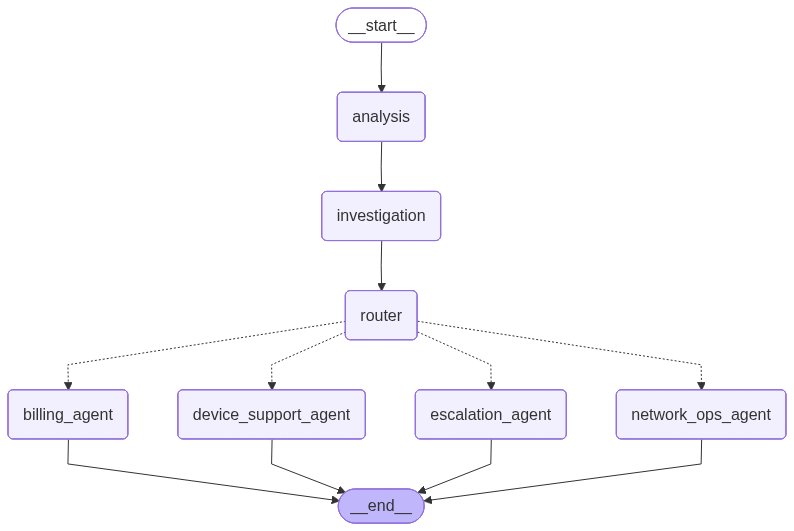

In [ ]:
incident_system


In [ ]:
# Test the Incident System
test_queries = [
    "Internet is extremely slow since morning in the downtown area.",
    "My SIM stopped working after recharge.",
    "Entire area has no signal and I need to make an emergency call."
]

for q in test_queries:
    print(f"\nProcessing Query: {q}")
    result = incident_system.invoke({"complaint": q})
    print(f"Route: {result['route']}")
    print(f"Resolution: {result['resolution_customer']}")

In [ ]:
res = incident_system.invoke({
   "complaint": "Internet is extremely slow since morning in the downtown area."
})
print(f"Route: {res['route']}")
print(f"Resolution: {res['resolution_customer']}")

Route: escalation_agent
Resolution: Here's the resolution:

---

### 1. Customer Message (Empathic Response)

"I understand how incredibly frustrating it is to experience extremely slow internet, especially when you need to get things done. I sincerely apologize for the inconvenience this has caused you since this morning.

We've identified a network issue impacting service quality in the downtown area, which is likely the cause of your slow speeds. Our technical teams are fully aware of the situation and are actively working to diagnose and resolve this degradation as quickly as possible. We are prioritizing this fix to restore full internet speeds to all affected customers.

Thank you for your patience while we work to get everything back to normal."

---

### 2. Internal Notes (Technical Summary for Technicians)

**Customer Report:** Customer in the downtown area reporting extremely slow internet speeds since morning.

**System Diagnosis:**
*   **Tower Status:** Degraded for the pri

In [ ]:
res = incident_system.invoke({
   "complaint": "My SIM stopped working after recharge."
})
print(f"Route: {res['route']}")
print(f"Resolution: {res['resolution_customer']}")

Route: escalation_agent
Resolution: Here's the resolution for the SIM issue:

---

**1. Customer Message:**

"I'm truly sorry to hear that your SIM stopped working right after you recharged it. I understand how frustrating and inconvenient this must be, especially when you've just topped up your service. This isn't the experience we want for you.

To get this resolved quickly, I'm escalating your case to a specialist agent who can perform a deeper dive into your account and network provisioning. They will investigate why your service isn't active despite your recent recharge. Your account is in good standing, and the network in your area is active, so we need to pinpoint the exact cause.

An agent will contact you shortly via [Preferred Contact Method - e.g., phone call, SMS] to troubleshoot further and restore your service. We appreciate your patience as we work to fix this for you."

---

**2. Internal Notes:**

**Issue:** SIM stopped working immediately post-recharge. Customer repor

## Healthcare Domain: Clinical Triage & Care Coordination System
This system automates patient triage by analyzing symptoms, assessing urgency, and routing to the appropriate medical specialist.

In [ ]:
import json
from typing import Annotated, List, Union
from typing_extensions import TypedDict

# --- 1. State Definition ---
class TriageState(TypedDict):
    patient_input: str
    symptoms: List[str]
    severity: str
    is_emergency: bool
    medical_guidance: str
    triage_summary: str
    route: str
    follow_up_plan: str


In [ ]:
# --- 2. Stage 1: Symptom Understanding (Optimized for Tokens) ---
def analyze_symptoms(state: TriageState):
    prompt = f"""
    Analyze: '{state['patient_input']}'
    Extract JSON ONLY (no markdown):
    {{"symptoms": [], "severity": "emergency/moderate/mild", "is_emergency": bool, "dept": "Cardiology/Neurology/Pharmacy/GP"}}
    """
    # Use invoke with a constraint to keep it short
    response = llm.invoke(prompt)
    content = response.content.strip().strip('`').replace('json', '').strip()
    data = json.loads(content)

    return {
        "symptoms": data.get("symptoms", []),
        "severity": data.get("severity", "moderate"),
        "is_emergency": data.get("is_emergency", False),
        "route": data.get("dept", "GP").lower().replace(' ', '_')
    }

In [ ]:
# --- 3. Stage 2: Knowledge Retrieval (Concise) ---
def retrieve_medical_context(state: TriageState):
    symptoms_str = ", ".join(state['symptoms'])
    prompt = f"List 3 diagnostic tests and 1 brief guideline for: {symptoms_str}. Max 50 words."
    response = llm.invoke(prompt)
    return {"medical_guidance": response.content}


In [ ]:
# --- 4. Stage 3 & 4: Specialist Agents (Concise Output) ---
def emergency_agent(state: TriageState):
    return {
        "triage_summary": "EMERGENCY: Immediate clinical intervention required.",
        "follow_up_plan": "Prep ER, notify on-call specialist."
    }

def specialist_agent(state: TriageState):
    prompt = f"""
    Task: Concise Triage Summary for {state['route']}.
    Input: {state['severity']} symptoms: {state['symptoms']}.
    Context: {state['medical_guidance']}
    Output: 2 sentences summary + 1 bullet for follow-up.
    """
    response = llm.invoke(prompt)
    return {"triage_summary": response.content, "follow_up_plan": "Schedule clinic visit."}


In [ ]:
# --- 5. Routing Logic ---
def healthcare_router(state: TriageState):
    if state['is_emergency'] or state['severity'] == "emergency":
        return "emergency_desk"
    # Handle abbreviated GP route from Stage 1
    return "general_physician" if state['route'] == "gp" else state['route']

In [ ]:
# --- 6. Build Graph ---
clinical_graph = StateGraph(TriageState)
clinical_graph.add_node("analyze", analyze_symptoms)
clinical_graph.add_node("retrieve", retrieve_medical_context)
clinical_graph.add_node("emergency_desk", emergency_agent)
clinical_graph.add_node("cardiology", specialist_agent)
clinical_graph.add_node("neurology", specialist_agent)
clinical_graph.add_node("pharmacy", specialist_agent)
clinical_graph.add_node("general_physician", specialist_agent)

clinical_graph.set_entry_point("analyze")
clinical_graph.add_edge("analyze", "retrieve")

clinical_graph.add_conditional_edges(
    "retrieve",
    healthcare_router,
    {
        "emergency_desk": "emergency_desk",
        "cardiology": "cardiology",
        "neurology": "neurology",
        "pharmacy": "pharmacy",
        "general_physician": "general_physician"
    }
)

clinical_graph.add_edge("emergency_desk", END)
clinical_graph.add_edge("cardiology", END)
clinical_graph.add_edge("neurology", END)
clinical_graph.add_edge("pharmacy", END)
clinical_graph.add_edge("general_physician", END)

clinical_triage_system = clinical_graph.compile()

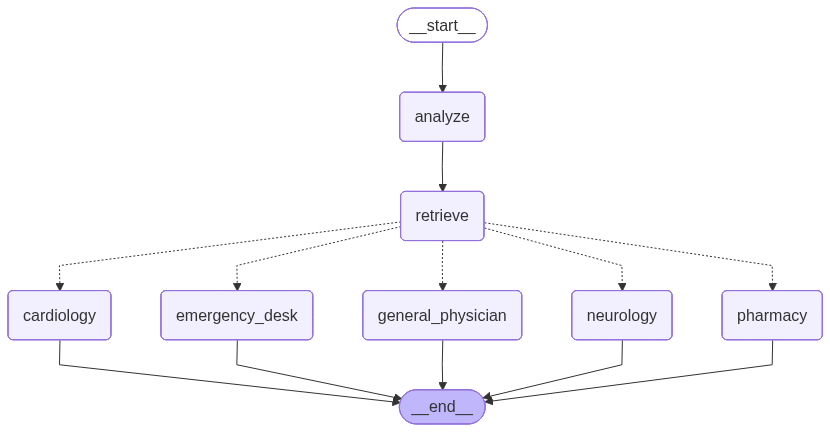

In [ ]:
clinical_triage_system

In [ ]:
case_input = "Chest pain and shortness of breath for the last 30 minutes."
result = clinical_triage_system.invoke({"patient_input": case_input})

print(f"Symptoms Identified: {result['symptoms']}")
print(f"Severity: {result['severity']}")
print(f"Route: {result['route']}")
print("\nTriage Summary:")
print(result['triage_summary'])
print("\nFollow-up Plan")
print(result['follow_up_plan'])


Symptoms Identified: ['Chest pain', 'Shortness of breath']
Severity: emergency
Route: cardiology

Triage Summary:
EMERGENCY: Immediate clinical intervention required.

Follow-up Plan
Prep ER, notify on-call specialist.


In [ ]:
case_input_2 = "Sudden dizziness and blurred vision for the past hour."
result_2 = clinical_triage_system.invoke({"patient_input": case_input_2})

print(f"Symptoms Identified: {result_2['symptoms']}")
print(f"Severity: {result_2['severity']}")
print(f"Route: {result_2['route']}")
print("\nTriage Summary:")
print(result_2['triage_summary'])
print("\nFollow-up Plan:")
print(result_2['follow_up_plan'])


Symptoms Identified: ['sudden dizziness', 'blurred vision']
Severity: emergency
Route: neurology

Triage Summary:
EMERGENCY: Immediate clinical intervention required.

Follow-up Plan:
Prep ER, notify on-call specialist.


In [ ]:
case_input_3 = "Fever and headache for 3 days."
result_3 = clinical_triage_system.invoke({"patient_input": case_input_3})

print(f"Symptoms Identified: {result_3['symptoms']}")
print(f"Severity: {result_3['severity']}")
print(f"Route: {result_3['route']}")
print("\nTriage Summary:")
print(result_3['triage_summary'])
print("\nFollow-up Plan:")
print(result_3['follow_up_plan'])


Symptoms Identified: ['fever', 'headache']
Severity: moderate
Route: gp

Triage Summary:
Patient presents with moderate fever and headache, typically managed with hydration, rest, and over-the-counter pain relief. Monitor symptoms closely, as high/persistent fever or sudden/severe headache changes warrant further medical evaluation.

*   Seek immediate care if fever becomes high/persistent, or headache changes suddenly/severely.

Follow-up Plan:
Schedule clinic visit.


In [ ]:
case_input_4 = "Mild skin rash after taking new medication yesterday."
result_4 = clinical_triage_system.invoke({"patient_input": case_input_4})

print(f"Symptoms Identified: {result_4['symptoms']}")
print(f"Severity: {result_4['severity']}")
print(f"Route: {result_4['route']}")
print("\nTriage Summary:")
print(result_4['triage_summary'])
print("\nFollow-up Plan:")
print(result_4['follow_up_plan'])


Symptoms Identified: ['skin rash']
Severity: mild
Route: gp

Triage Summary:
A mild skin rash is a common presentation, often self-limiting or manageable with basic care. However, its persistence, worsening, or association with systemic symptoms necessitates further evaluation to identify the underlying cause.

*   Referral to dermatology or consideration of diagnostic tests (e.g., skin biopsy, swab for culture, blood tests) if the rash is concerning or fails to improve.

Follow-up Plan:
Schedule clinic visit.


## Finance Domain: Intelligent Loan Risk Assessment & Approval System
Automates loan processing by analyzing income, creditworthiness, and fraud risk to orchestrate approval decisions.

In [ ]:
import json
from typing import Annotated, List, Union
from typing_extensions import TypedDict

# --- 1. State Definition ---
class LoanState(TypedDict):
    applicant_data: str
    profile: dict
    credit_score: int
    fraud_risk: str # low, medium, high
    debt_to_income: float
    decision_route: str
    rationale: str
    recommendation: dict

In [ ]:
# --- 2. Stage 1: Applicant Analysis ---
def analyze_applicant(state: LoanState):
    prompt = f"""
    Analyze Applicant Data: '{state['applicant_data']}'
    Extract JSON:
    {{"income": float, "employment": "string", "score_hint": int, "missing_docs": [], "spending_pattern": "stable/unstable"}}
    """
    response = llm.invoke(prompt)
    data = json.loads(response.content.strip().strip('`').replace('json', '').strip())
    return {"profile": data, "credit_score": data.get("score_hint", 0)}

In [ ]:
# --- 3. Stage 2: Verification Layer (Parallel capable logic) ---
def verify_credit_and_fraud(state: LoanState):
    profile = state['profile']
    credit = state['credit_score']

    fraud_status = "low"
    if profile.get("spending_pattern") == "unstable" or credit < 500:
        fraud_status = "medium"

    # DTI calculation simulation
    dti = 0.35 if profile.get("income", 0) > 5000 else 0.55

    return {"fraud_risk": fraud_status, "debt_to_income": dti}

In [ ]:
# --- 4. Stage 3 & 4: Decision Nodes & Routing ---
def fast_track_agent(state: LoanState):
    return {"rationale": "Excellent credit and low risk.", "recommendation": {"status": "Approved", "amount": "Requested", "interest": "4.5%"}}

def manual_review_agent(state: LoanState):
    return {"rationale": "Medium risk or DTI concerns.", "recommendation": {"status": "Pending", "amount": "Reduced", "interest": "7.5%"}}

def rejection_agent(state: LoanState):
    return {"rationale": "High risk of fraud or poor credit.", "recommendation": {"status": "Rejected", "amount": 0, "interest": "N/A"}}

def loan_router(state: LoanState):
    if state['fraud_risk'] == "high" or state['credit_score'] < 400:
        return "reject"
    if state['credit_score'] > 750 and state['debt_to_income'] < 0.4:
        return "fast_track"
    return "manual_review"

In [ ]:
# --- 5. Build Graph ---
loan_graph = StateGraph(LoanState)

loan_graph.add_node("analyze", analyze_applicant)
loan_graph.add_node("verify", verify_credit_and_fraud)
loan_graph.add_node("fast_track", fast_track_agent)
loan_graph.add_node("manual_review", manual_review_agent)
loan_graph.add_node("reject", rejection_agent)

loan_graph.set_entry_point("analyze")
loan_graph.add_edge("analyze", "verify")

loan_graph.add_conditional_edges(
    "verify",
    loan_router,
    {
        "fast_track": "fast_track",
        "manual_review": "manual_review",
        "reject": "reject"
    }
)

loan_graph.add_edge("fast_track", END)
loan_graph.add_edge("manual_review", END)
loan_graph.add_edge("reject", END)

loan_system = loan_graph.compile()


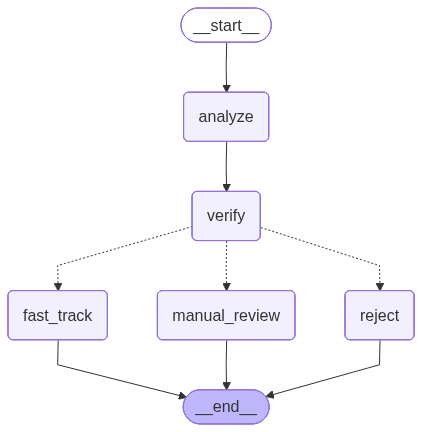

In [ ]:
loan_system

In [ ]:
applicant_input = "Name: Ramesh, Salary: 30000Rs/mo, Credit Score: 800, Debt: 10000, All documents submitted."
loan_result = loan_system.invoke({"applicant_data": applicant_input})

print(f"Credit Score: {loan_result['credit_score']}")
print(f"Risk Level: {loan_result['fraud_risk']}")
print(f"Decision: {loan_result['recommendation']['status']}")
print(f"Rationale: {loan_result['rationale']}")
print(f"Terms: {loan_result['recommendation']}")

Credit Score: 800
Risk Level: low
Decision: Approved
Rationale: Excellent credit and low risk.
Terms: {'status': 'Approved', 'amount': 'Requested', 'interest': '4.5%'}


In [ ]:
applicant_input_2 = "Name: Priya, Salary: 4500Rs/mo, Credit Score: 620, Debt: 2000, missing income certificate."
loan_result_2 = loan_system.invoke({"applicant_data": applicant_input_2})

print(f"Credit Score: {loan_result_2['credit_score']}")
print(f"Risk Level: {loan_result_2['fraud_risk']}")
print(f"Decision: {loan_result_2['recommendation']['status']}")
print(f"Rationale: {loan_result_2['rationale']}")
print(f"Terms: {loan_result_2['recommendation']}")

Credit Score: 620
Risk Level: low
Decision: Pending
Rationale: Medium risk or DTI concerns.
Terms: {'status': 'Pending', 'amount': 'Reduced', 'interest': '7.5%'}


In [ ]:
applicant_input_3 = "Name: Sam, Salary: 2000Rs/mo, Credit Score: 350, Debt: 15000, high credit utilization."
loan_result_3 = loan_system.invoke({"applicant_data": applicant_input_3})

print(f"Credit Score: {loan_result_3['credit_score']}")
print(f"Risk Level: {loan_result_3['fraud_risk']}")
print(f"Decision: {loan_result_3['recommendation']['status']}")
print(f"Rationale: {loan_result_3['rationale']}")

Credit Score: 350
Risk Level: medium
Decision: Rejected
Rationale: High risk of fraud or poor credit.


In [ ]:
applicant_input_4 = "Name: Ajay, Salary: 10000Rs/mo, Credit Score: 700, Debt: 1000, frequent gambling transactions and unstable spending."
loan_result_4 = loan_system.invoke({"applicant_data": applicant_input_4})

print(f"Spending Pattern: {loan_result_4['profile'].get('spending_pattern')}")
print(f"Risk Level: {loan_result_4['fraud_risk']}")
print(f"Decision: {loan_result_4['recommendation']['status']}")
print(f"Rationale: {loan_result_4['rationale']}")

Spending Pattern: unstable
Risk Level: medium
Decision: Pending
Rationale: Medium risk or DTI concerns.
